In [4]:
import pandas as pd
import numpy as np
import seaborn as sns
from matplotlib import pyplot as plt

from rdkit import Chem, RDLogger, DataStructs
from rdkit.Chem import rdFingerprintGenerator
from rdkit.ML.Cluster import Butina

import warnings

RDLogger.DisableLog("rdApp.warning")
warnings.filterwarnings('ignore', module='upsetplot')

In [5]:
data = pd.read_csv("all_chem_df.csv")

data["tags"] = data["tags"].fillna("").str.split()
data = data.drop(["image_name", "Col3"], axis=1)
data = data[sorted(data.columns)]

data = data.explode("tags")
data

,smiles,tags
0,CC(=O)NC1C(O)OC(CO)C(O)C1O,dermatologic
1,CCC[C@@]1(CCc2ccccc2)CC(O)=C([C@H](CC)c2cccc(N...,antiinfective
2,CCCCC(C)C(=O)OC1C(C)C(CC)OC2(CC3CC(C/C=C(\C)CC...,antiinfective
3,COc1cc2c(c(OC)c1OC)-c1c(cc3c(c1OC)OCO3)C[C@H](...,antineoplastic
4,CC(=O)N[C@@H](CS)C(=O)[O-],antiinfective
...,...,...
8331,CC(=O)Oc1ccccc1C(=O)O.OCCN(CCO)c1nc(N2CCCCC2)c...,hematologic
8332,C=CO.C=O,hematologic
8333,CC1(C)SC2[C@H](NC(=O)[C@H](N)c3ccccc3)C(=O)N2[...,antiinfective
8334,COCCCOc1ccnc(C[S@@](=O)c2nc3ccccc3[nH]2)c1C,gastrointestinal


---

# Overview

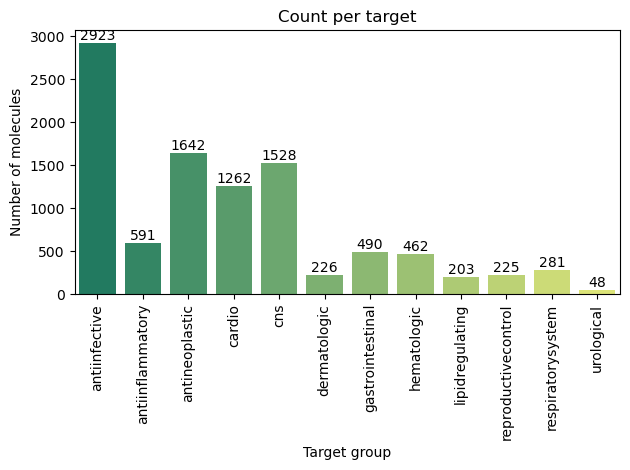

In [6]:
counts = data.groupby("tags")["smiles"].count().reset_index(name="n")

ax = sns.barplot(data=counts, x="tags", y="n", palette="summer", hue="tags")
for container in ax.containers:
    ax.bar_label(container)
    
plt.ylabel("Number of molecules")
plt.xlabel("Target group")
plt.title("Count per target")
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

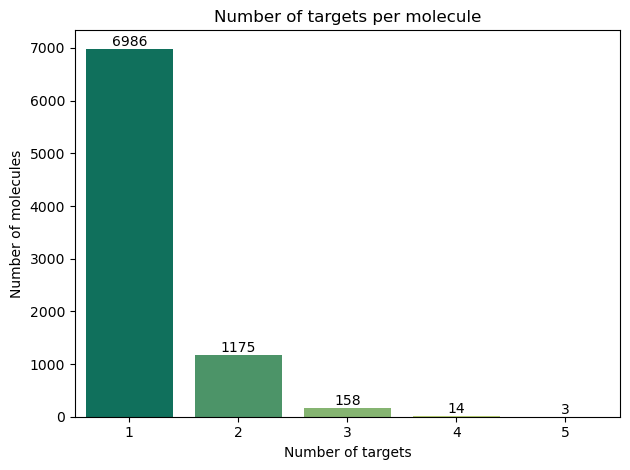

In [7]:
target_counts = (data.groupby("smiles")["tags"].nunique().value_counts().sort_index()).to_frame().reset_index()

ax = sns.barplot(data=target_counts, x="tags", y="count", palette="summer", hue="tags", legend=False)
    
for container in ax.containers:
    ax.bar_label(container)
    
plt.ylabel("Number of molecules")
plt.xlabel("Number of targets")
plt.title("Number of targets per molecule")
plt.tight_layout()
plt.show()

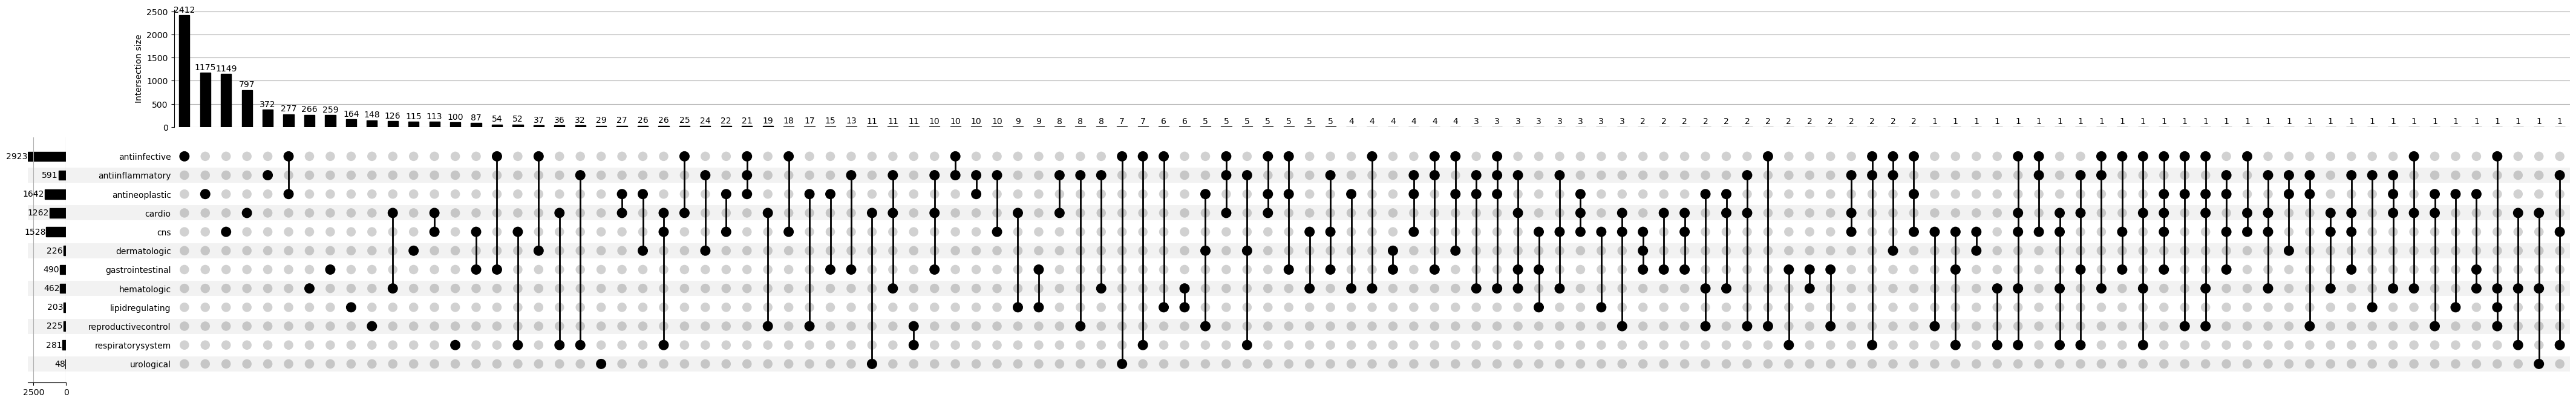

In [8]:
from upsetplot import from_contents, UpSet

targets = list(set(data["tags"]))

target_smiles_dict = (
    data[data["tags"].isin(targets)]
    .groupby("tags")["smiles"]
    .apply(list)
    .to_dict()
)

upsetDict = from_contents(target_smiles_dict)
ax_dict = UpSet(upsetDict, subset_size="count", show_counts=True, sort_by="cardinality", sort_categories_by="-input").plot()

Canonizing SMILES

In [9]:
def canonize(mol):
    return Chem.MolToSmiles(Chem.MolFromSmiles(mol), isomericSmiles=True, canonical=True)

data["canon_smiles"] = data["smiles"].apply(canonize)

Applying descriptors

In [10]:
from rdkit.Chem import Descriptors

data["mol"] = data["canon_smiles"].apply(lambda x: Chem.MolFromSmiles(x)) 
data["mol"] = data["mol"].apply(lambda x: Chem.AddHs(x))

data["num_of_atoms"] = data["mol"].apply(lambda x: x.GetNumAtoms())

data["num_of_heavy_atoms"] = data["mol"].apply(lambda x: x.GetNumHeavyAtoms())

data["TPSA"] = data["mol"].apply(lambda x: round(Descriptors.TPSA(x), 2))

data["exact_mol_wt"] = data["mol"].apply(lambda x: round(Descriptors.ExactMolWt(x), 2))

data["h_d"] = data["mol"].apply(lambda x: Descriptors.NumHDonors(x))

data["h_a"] = data["mol"].apply(lambda x: Descriptors.NumHAcceptors(x))

data["log_p"] = data["mol"].apply(lambda x: round(Descriptors.MolLogP(x), 2))

In [11]:
data.describe()
data

,smiles,tags,canon_smiles,mol,num_of_atoms,num_of_heavy_atoms,TPSA,exact_mol_wt,h_d,h_a,log_p
0,CC(=O)NC1C(O)OC(CO)C(O)C1O,dermatologic,CC(=O)NC1C(O)OC(CO)C(O)C1O,<rdkit.Chem.rdchem.Mol object at 0x31ff08190>,30,15,119.25,221.09,5,6,-3.08
1,CCC[C@@]1(CCc2ccccc2)CC(O)=C([C@H](CC)c2cccc(N...,antiinfective,CCC[C@@]1(CCc2ccccc2)CC(O)=C([C@H](CC)c2cccc(N...,<rdkit.Chem.rdchem.Mol object at 0x31ff08200>,75,42,105.59,602.21,2,6,7.33
2,CCCCC(C)C(=O)OC1C(C)C(CC)OC2(CC3CC(C/C=C(\C)CC...,antiinfective,CCCCC(C)C(=O)OC1C(C)C(CC)OC2(CC3CC(C/C=C(\C)CC...,<rdkit.Chem.rdchem.Mol object at 0x31ff08270>,107,49,140.98,686.40,3,10,5.24
3,COc1cc2c(c(OC)c1OC)-c1c(cc3c(c1OC)OCO3)C[C@H](...,antineoplastic,COc1cc2c(c(OC)c1OC)-c1c(cc3c(c1OC)OCO3)C[C@H](...,<rdkit.Chem.rdchem.Mol object at 0x31ff082e0>,58,30,75.61,416.18,1,7,3.60
4,CC(=O)N[C@@H](CS)C(=O)[O-],antiinfective,CC(=O)N[C@@H](CS)C(=O)[O-],<rdkit.Chem.rdchem.Mol object at 0x31ff08350>,18,10,69.23,162.02,2,4,-1.83
...,...,...,...,...,...,...,...,...,...,...,...
8331,CC(=O)Oc1ccccc1C(=O)O.OCCN(CCO)c1nc(N2CCCCC2)c...,hematologic,CC(=O)Oc1ccccc1C(=O)O.OCCN(CCO)c1nc(N2CCCCC2)c...,<rdkit.Chem.rdchem.Mol object at 0x32fe18890>,97,49,209.04,684.36,5,16,1.29
8332,C=CO.C=O,hematologic,C=CO.C=O,<rdkit.Chem.rdchem.Mol object at 0x32fe18900>,11,5,37.30,74.04,1,2,0.50
8333,CC1(C)SC2[C@H](NC(=O)[C@H](N)c3ccccc3)C(=O)N2[...,antiinfective,CC1(C)SC2[C@H](NC(=O)[C@H](N)c3ccccc3)C(=O)N2[...,<rdkit.Chem.rdchem.Mol object at 0x32fe18970>,57,34,128.03,481.13,2,8,1.65
8334,COCCCOc1ccnc(C[S@@](=O)c2nc3ccccc3[nH]2)c1C,gastrointestinal,COCCCOc1ccnc(C[S@@](=O)c2nc3ccccc3[nH]2)c1C,<rdkit.Chem.rdchem.Mol object at 0x32fe189e0>,46,25,77.10,359.13,1,5,2.99


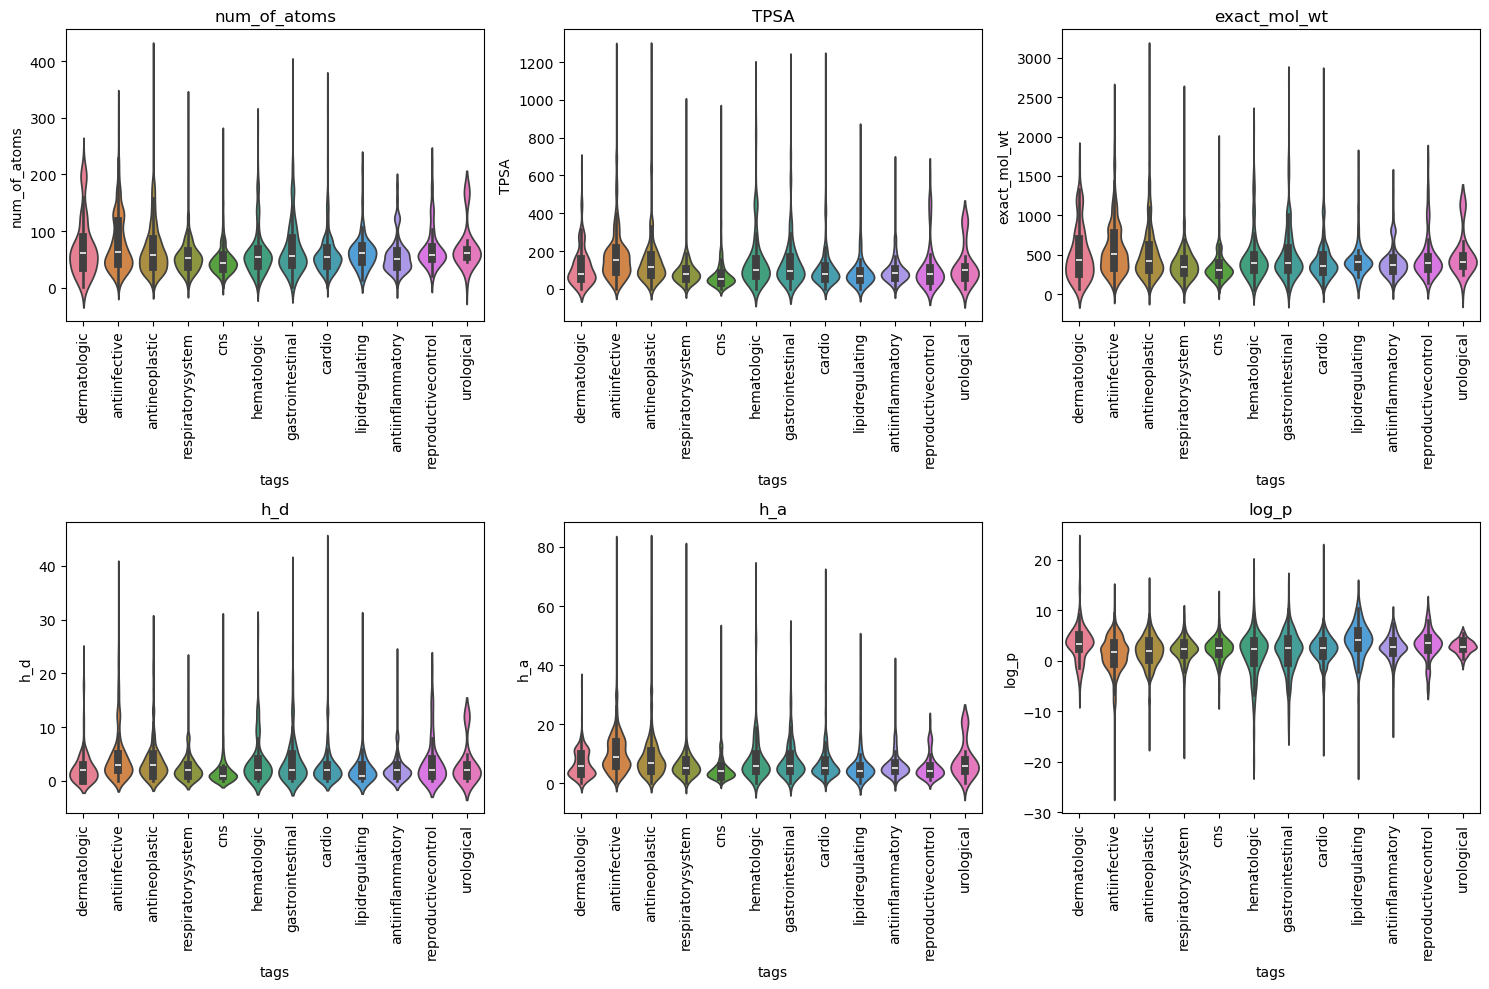

In [12]:
features = ["num_of_atoms", "TPSA", "exact_mol_wt", "h_d", "h_a", "log_p"]
plt.figure(figsize=(15, 10))
for i, feature in enumerate(features, 1):
    plt.subplot(2, 3, i)
    sns.violinplot(x="tags", y=feature, data=data, hue="tags", legend=False)
    plt.title(feature)
    plt.ylabel(feature)
    plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

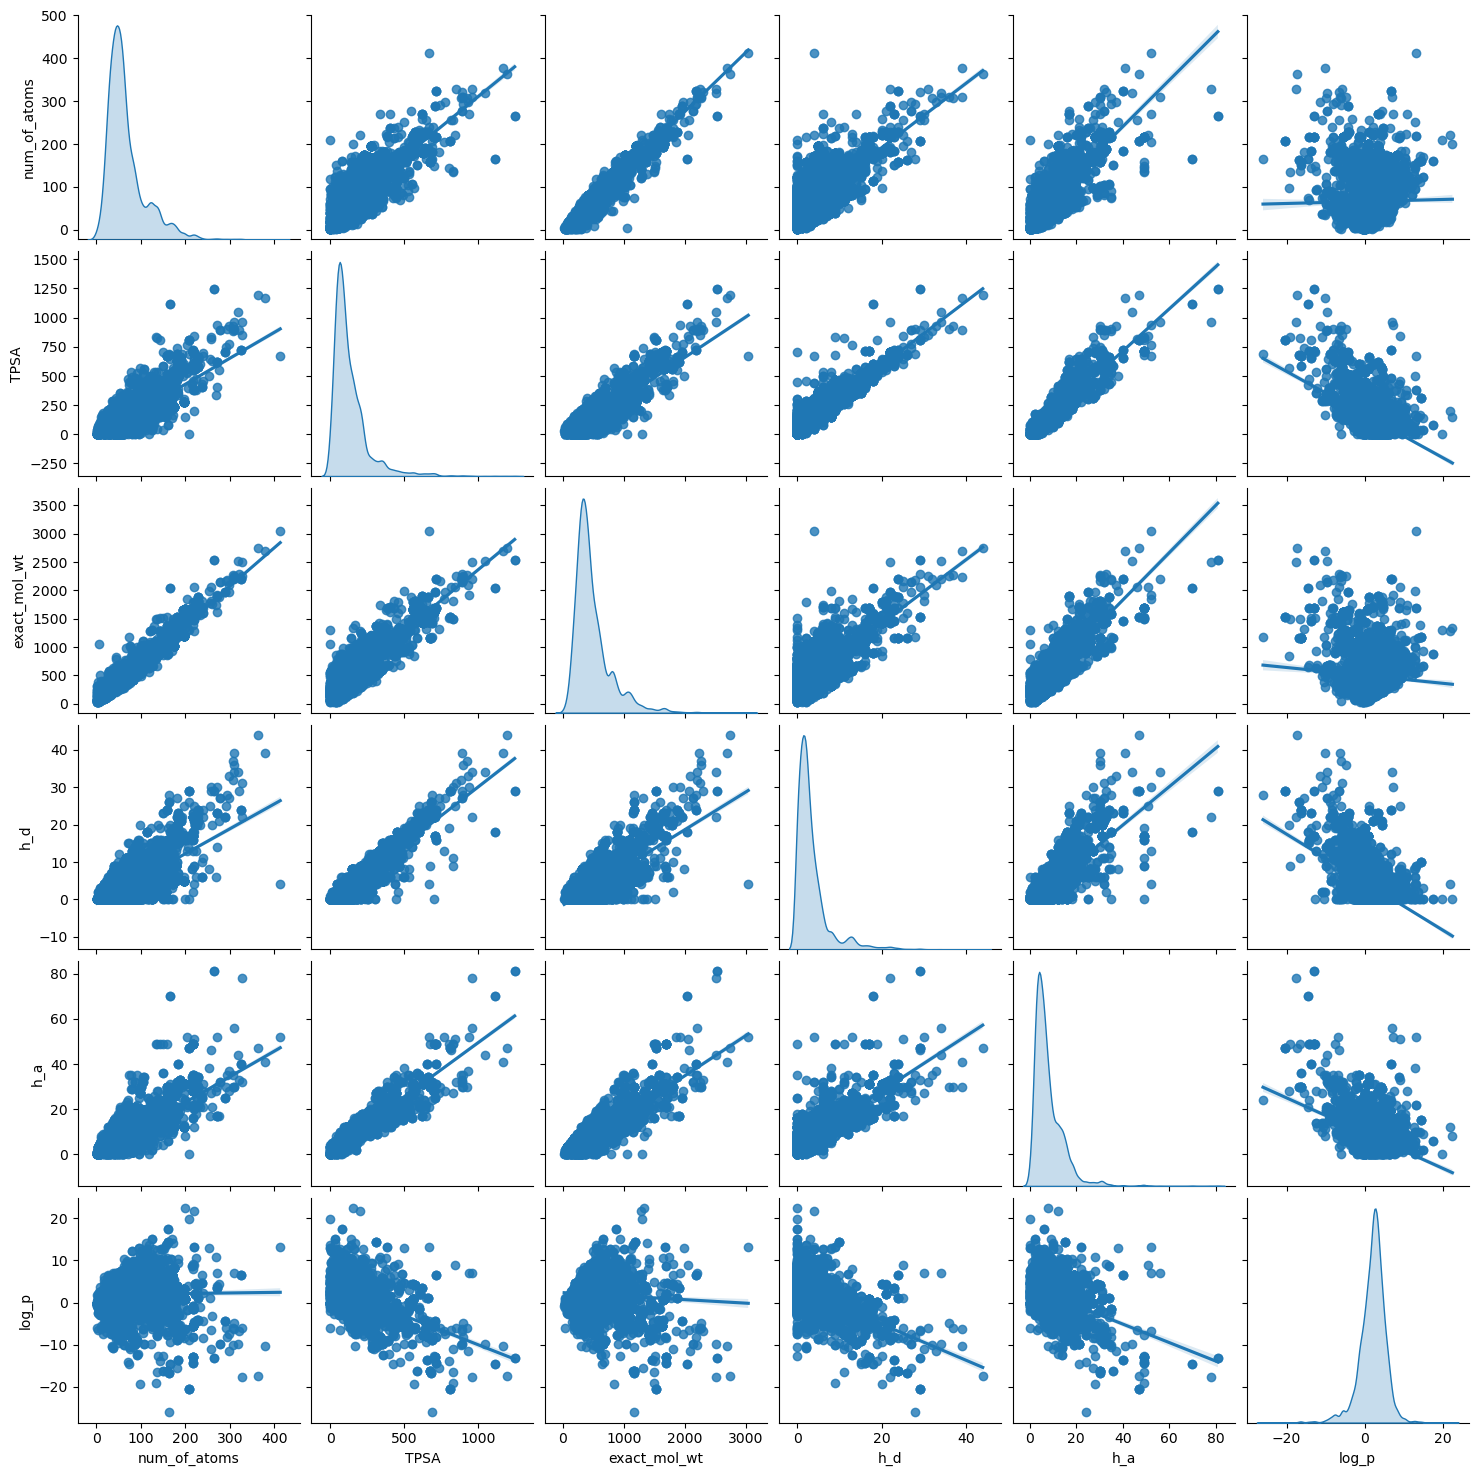

In [13]:
sns.pairplot(data[["num_of_atoms", "TPSA", "exact_mol_wt", "h_d", "h_a", "log_p"]], diag_kind="kde", kind="reg")
plt.show()

---

# Clustering

Sanitize smiles, generate fingerprints

In [14]:
data_mol = []
for _, smiles in data["smiles"].items():
    data_mol.append(Chem.MolFromSmiles(smiles))

In [15]:
rdkitGen = rdFingerprintGenerator.GetMorganGenerator(radius = 2, fpSize = 2048)
data_fp = [rdkitGen.GetFingerprint(mol) for mol in data_mol]

print(f"Number of compounds converted: {len(data_fp)}")
print(f"Fingerprint length per compound: {len(data_fp[0])}")

Number of compounds converted: 9881
Fingerprint length per compound: 2048


2 supporting functions: one generating distance matrix for molecules, second for clustering them using Butina algo

In [16]:
def tanimotoDistanceMatrix(fpList):
    """
    generate Tanimoto distance matrix
    input: list of fingerprints
    output: matrix of distances between each molecule
    """
    dissimilarityMatrix = []
    for i in range (1, len(fpList)):
        similarities = DataStructs.BulkTanimotoSimilarity(fpList[i], fpList[:i])
        dissimilarityMatrix.extend([1 - x for x in similarities])
    return dissimilarityMatrix

def clusterFingerprints(fingerprints, cutoff):
    """cluster fingerprints using Butina based on pre-set cutoff
    input: list of fingerprints, cutoff[0;1]
    output: a tuple of tuples containing information about the clusters; first element for each cluster is its centroid
    *higher cutoff = less clusters, bigger diversity within a cluster
    """
    distanceMatrix = tanimotoDistanceMatrix(fingerprints)
    clusters = Butina.ClusterData(distanceMatrix, len(fingerprints), cutoff, isDistData = True)
    clusters = sorted(clusters, key = len, reverse = True)
    return clusters

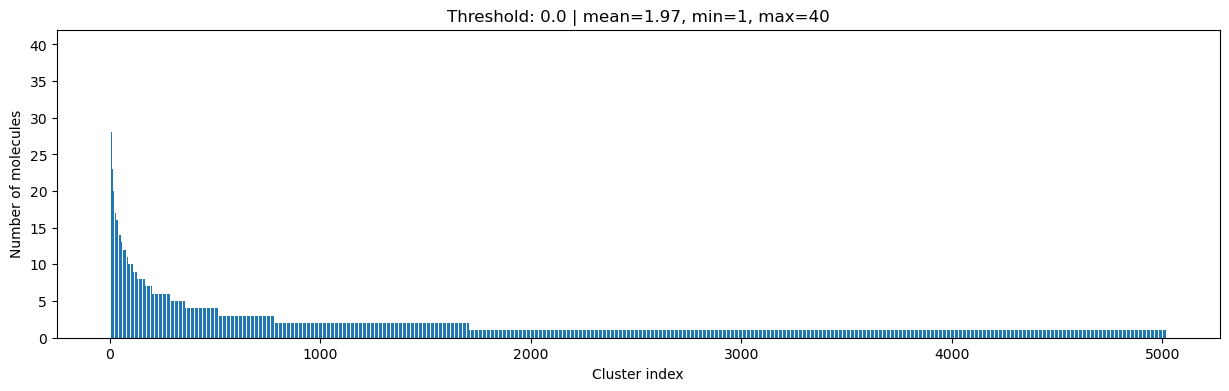

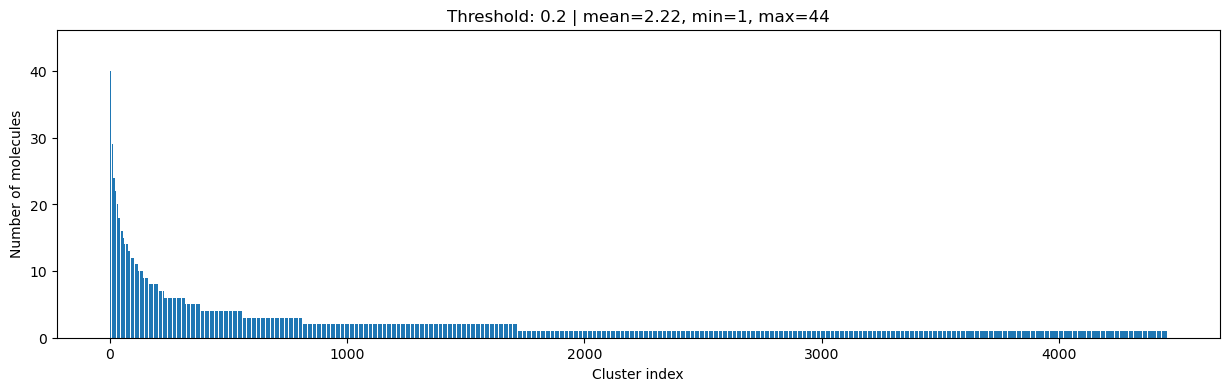

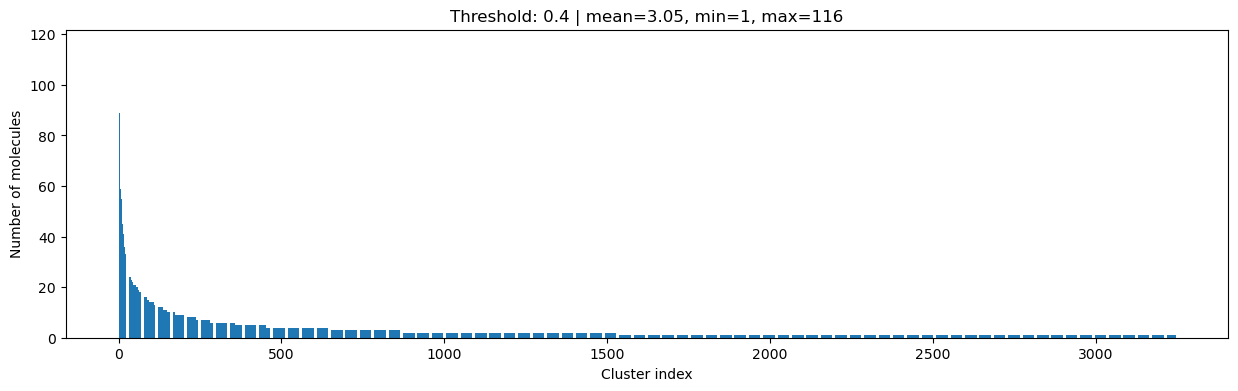

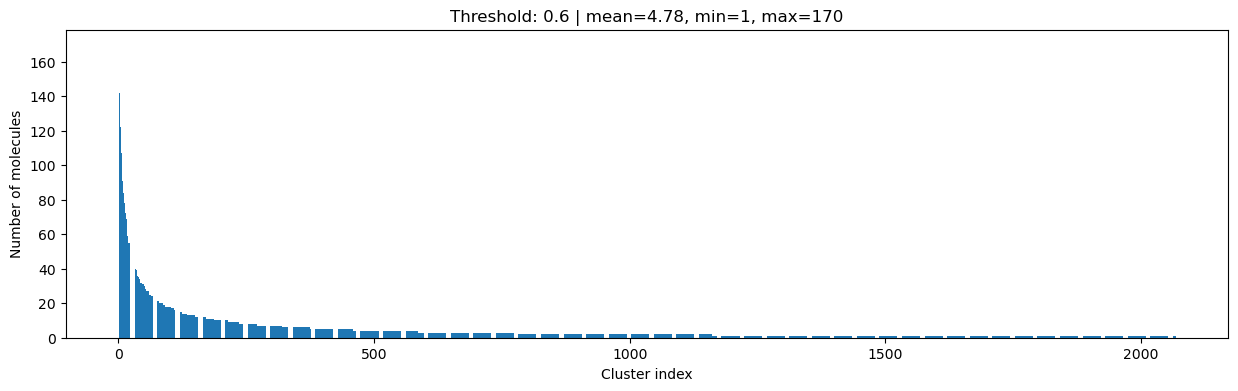

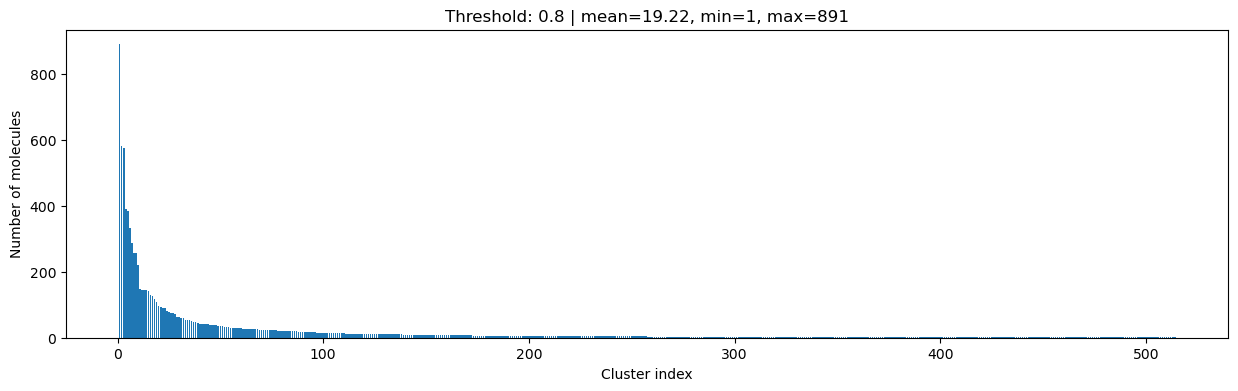

In [17]:
for cutoff in np.arange(0.0, 1.0, 0.2):
    clusters = clusterFingerprints(data_fp, cutoff=cutoff)
    sizes = np.array([len(c) for c in clusters])
    
    fig, ax = plt.subplots(figsize=(15, 4))
    ax.set_title(f"Threshold: {cutoff:2.1f} | mean={sizes.mean():.2f}, min={sizes.min()}, max={sizes.max()}")
    ax.set_xlabel("Cluster index")
    ax.set_ylabel("Number of molecules")
    ax.bar(range(1, len(clusters) + 1), [len(c) for c in clusters], lw=5)

The compounds don't really cluster - there is no relevance between fp and known target 

---

# Clustering only dermatologic data

In [18]:
mask = data["tags"] == "dermatologic"
dermatologic_data = data[mask].reset_index(drop=True)
dermatologic_data_fp = [rdkitGen.GetFingerprint(mol) for mol in dermatologic_data["mol"]]
print(f"Number of compounds converted: {len(dermatologic_data_fp)}")

Number of compounds converted: 226


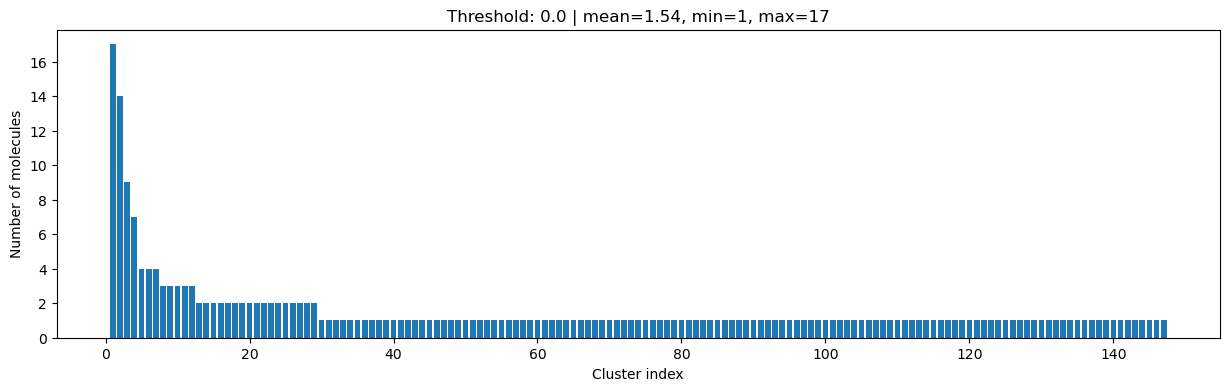

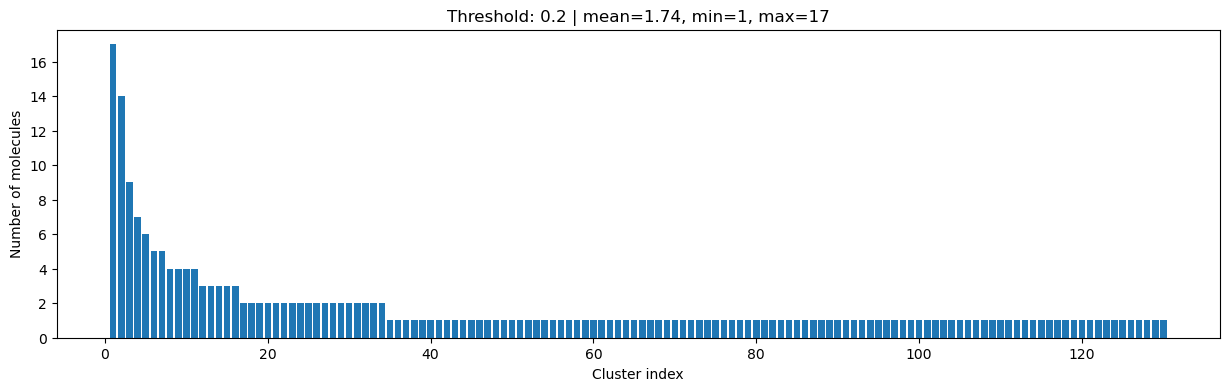

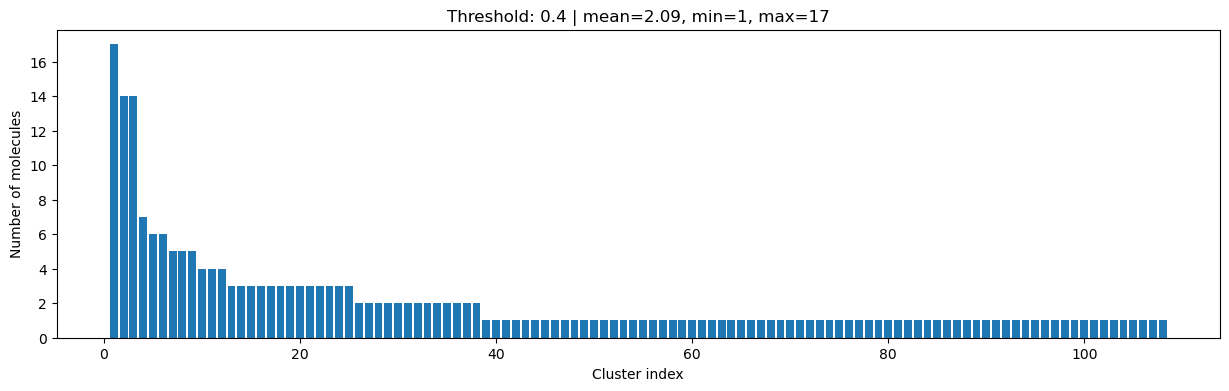

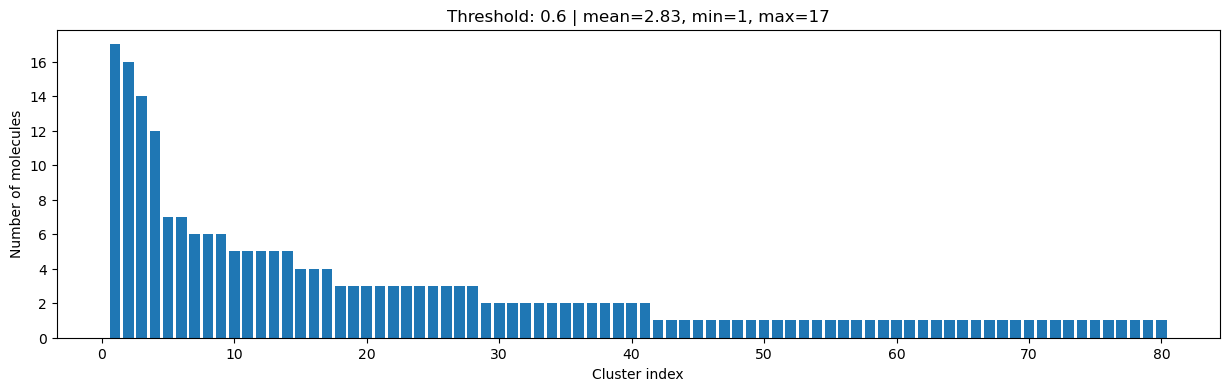

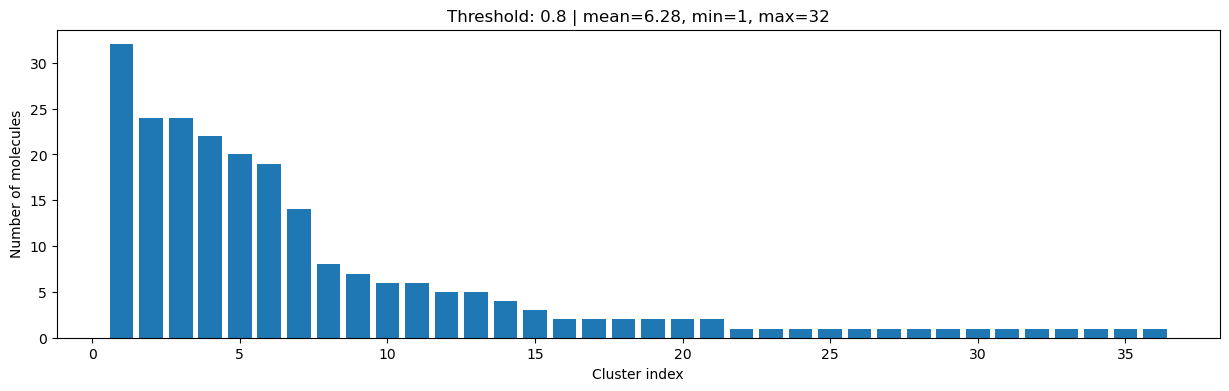

In [19]:
for cutoff in np.arange(0.0, 1.0, 0.2):
    clusters = clusterFingerprints(dermatologic_data_fp, cutoff=cutoff)
    sizes = np.array([len(c) for c in clusters])
    
    fig, ax = plt.subplots(figsize=(15, 4))
    ax.set_title(f"Threshold: {cutoff:2.1f} | mean={sizes.mean():.2f}, min={sizes.min()}, max={sizes.max()}")
    ax.set_xlabel("Cluster index")
    ax.set_ylabel("Number of molecules")
    ax.bar(range(1, len(clusters) + 1), [len(c) for c in clusters], lw=5)

Even within a known group of targets - dermatologic - little to no similarity

___

# Bioisosteric replacement

==> licencjat_test_modeli.ipynb